# 02-04 - A Map for the Lobby

The last notebook made its decisions on a grid that nobody in the municipal building uses. Now we make the map the December poster will need, on the municipality's own tax blocks, and we make every decision the lecture listed out loud: the denominator, the universe, the classification, the colour, and then the anatomy. We export it in the file type a printer wants.

Write the caption before you export, on paper if you like, because a map whose caption you cannot finish is not finished either. The agent in Wednesday's demo is handed an export exactly like the one this notebook writes. Save your own copy first, with `-mywork` in the name. The maps this notebook writes go into a folder called `output` beside it, which git ignores, so nothing you export here can collide with next week's pull.

In [1]:
import json
import warnings
from datetime import date
from pathlib import Path

import geopandas as gpd
import mapclassify
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

warnings.filterwarnings("ignore", message="Numba not installed")   # the one warning this course silences, see 02-03
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Rebuilding the blocks in one cell

In 02-02 we spent a whole notebook getting from parcels to one number per block, and we found the two traps on the way. Here is the same journey in one cell, with both decisions written down where they are made, plus three new lines, each marked with a comment. `agg` computes several summaries per block in one call and names them; a second `groupby` sums the taxable parcels only; and the last line turns square metres into acres:

In [2]:
metric = "EPSG:26918"
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels").to_crs(metric)
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks").to_crs(metric)

centres = tax_roll.copy()
centres["geometry"] = centres.geometry.centroid   # 02-02's other decision, six parcels whose centroid falls in no block are lost here
assigned = gpd.sjoin(centres, blocks[["BLOCK_NO", "geometry"]], predicate="within")
assigned = assigned.drop_duplicates("PAMS_PIN")          # five parcels sit in two overlapping blocks, keep one row each

exempt = assigned["PROP_CLASS"].astype(str).str.startswith("15")
per_block = assigned.groupby("BLOCK_NO").agg(total=("NET_VALUE", "sum"), parcels=("NET_VALUE", "size"))   # new, two summaries at once
per_block["taxable"] = assigned[~exempt].groupby("BLOCK_NO")["NET_VALUE"].sum()                          # new, the taxable parcels only

block_value = blocks.dissolve(by="BLOCK_NO")[["geometry"]].join(per_block)
block_value["acres"] = block_value.geometry.area / 4046.856   # new, square metres to acres, from geometry in metres

print(f"{len(block_value)} blocks, {int(block_value['total'].notna().sum())} with parcels, {int(block_value['taxable'].notna().sum())} with taxable parcels")

455 blocks, 450 with parcels, 425 with taxable parcels


Note the comments on the join and on the acres. The `drop_duplicates` line is the decision from 02-02 about the five parcels that sit in two overlapping blocks, and the acres line says where the denominator comes from, i.e. from the block's own geometry in metres, not from a column somebody typed. A reader of this notebook can see both choices without asking. That is what "state your denominator" looks like in code.

There are now two value columns. `total` is the assessed value of every parcel in the block. `taxable` is the assessed value of the parcels that actually pay property tax, i.e. everything except class 15. The gap between them is the campus, the churches, the schools and the public land, and the difference between the two columns is the difference between two maps a municipal reader might ask for. Note that the second `groupby` has no row at all for a block whose parcels are every one exempt, so aligning it onto `per_block` leaves `taxable` empty there rather than zero, which is why the line above counts more blocks with parcels than with taxable parcels. What that emptiness means for a map is the business of the universe section below.

## The first map, of where the large blocks are

The ramp is the one 02-03 settled on, i.e. a single hue from light to dark built on the course orange, because the quantity has an order and no meaningful middle, so a diverging ramp would invent one.

Let us draw the total, classified into five quantiles, which is the choice 02-03 argued for:

correlation between a block's total value and its area: 0.26


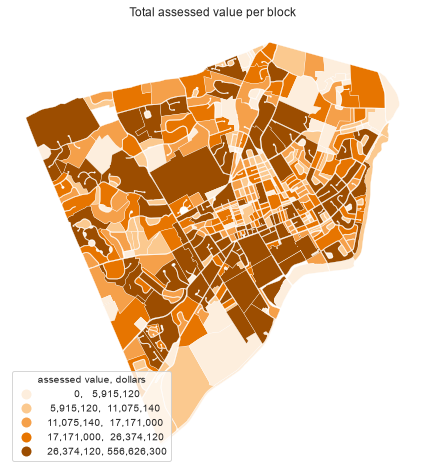

In [3]:
ORANGES = ListedColormap(["#fdeedd", "#fbc98f", "#f5a04a", "#e77500", "#9c4d00"])

ax = block_value.plot(column="total", scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.3,
                      figsize=(8, 8), legend=True, legend_kwds={"loc": "lower left", "fmt": "{:,.0f}", "title": "assessed value, dollars"})
ax.set_title("Total assessed value per block")
ax.set_axis_off()

print(f"correlation between a block's total value and its area: {block_value['total'].corr(block_value.geometry.area):.2f}")

A map of a total is, in part, a map of how big the zones are. A block twice the size has room for twice the houses, so its total is larger whether or not anything about it is different. The correlation printed under the map says how much of that is going on here. A correlation of zero would mean that a block's size tells you nothing about its total, and one would mean that it tells you everything. The printed value is modest, i.e. size explains part of a block's total and nothing like all of it, and the two lines below show where it comes apart.

The lecture's rule was that only a quantity that could be true of every part of a zone belongs on a choropleth. A total is not that. A rate is. Let us divide by the acres, and print the size of the leading blocks under each measure:

In [4]:
block_value["per_acre"] = block_value["total"] / block_value["acres"]

by_total = set(block_value["total"].nlargest(3).index)
by_rate = set(block_value["per_acre"].nlargest(3).index)

exempt_share = 1 - block_value["taxable"].fillna(0) / block_value["total"]

print(f"top three blocks by total value    {sorted(by_total)}   acres {block_value.loc[sorted(by_total), 'acres'].round(0).astype(int).tolist()}   share exempt {exempt_share[sorted(by_total)].round(2).tolist()}")
print(f"top three blocks by value per acre {sorted(by_rate)}   acres {block_value.loc[sorted(by_rate), 'acres'].round(1).tolist()}   share exempt {exempt_share[sorted(by_rate)].round(2).tolist()}")
print(f"blocks in both lists               {len(by_total & by_rate)}")

top three blocks by total value    ['10801', '45.01', '50.01']   acres [122, 86, 148]   share exempt [0.99, 0.98, 0.95]
top three blocks by value per acre ['20.01', '20.03', '27.01']   acres [2.2, 0.9, 3.0]   share exempt [0.0, 0.0, 0.39]
blocks in both lists               0


Two lists of three, and they share nothing. Look at the acres and the exempt share beside them. The blocks that carry the most value are large and almost entirely exempt, i.e. they are the University's, and a map of totals is in good part a map of the campus. The blocks that carry the most value per acre are small and downtown, where a few parcels are worth a great deal. Deciding to divide by area changed which blocks a reader would point at, and it is the same data. The exempt share is the next section's business.

The pipeline recorded the same overlap, so let us compare:

In [5]:
reference = json.load(open("data/ground_truth.json"))["p02"]
reference["blocks"]

{'with_parcels': 450,
 'corr_total_area': 0.26,
 'top3_overlap': 0,
 'per_acre_ratio_top_to_bottom_class': 24.1,
 'with_taxable_parcels': 425,
 'taxable_per_acre_ratio_top_to_bottom_class': 21.0,
 'taxable_breaks_usd_per_acre': [438371, 965372, 1789997, 3119883, 52862549],
 'taxable_occupancy': [85, 85, 85, 85, 85],
 'taxable_top3': [{'block': '20.03', 'usd_per_acre': 52862549},
  {'block': '20.01', 'usd_per_acre': 26060608},
  {'block': '20.04', 'usd_per_acre': 23147833}]}

Four of the six entries are the numbers we have just printed, i.e. 450 blocks with parcels, 425 with taxable parcels, a correlation of 0.26 and no block in both lists of three. The other two are ratios, and the poster's title will use one of them.

## The universe, or what zero means

Before drawing the rate, one more decision. Should the campus be on this map? Its parcels are assessed, so they have a value per acre and a high one, but they pay no tax. A reader in the municipal lobby who asks "where is our tax base" does not mean the E-Quad. So the map for the lobby is taxable value per acre, and a block with no taxable parcel at all is not zero, it is a different thing, and it needs its own mark.

Here is what happens if we draw it without deciding that:

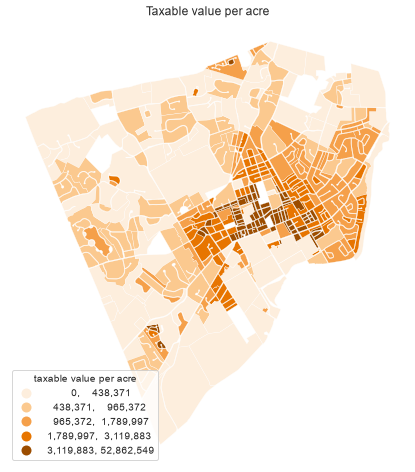

In [6]:
block_value["taxable_per_acre"] = block_value["taxable"] / block_value["acres"]

ax = block_value.plot(column="taxable_per_acre", scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.3,
                      figsize=(8, 8), legend=True, legend_kwds={"loc": "lower left", "fmt": "{:,.0f}", "title": "taxable value per acre"})
ax.set_title("Taxable value per acre")
ax.set_axis_off()

Look at the middle of the map. The campus blocks are simply not there. geopandas drops rows whose value is missing and says nothing, so the reader sees white where the University is, with no entry in the legend to explain it, and white in a choropleth reads as "nothing here". That is a silent failure of exactly the kind this course keeps meeting. The fix is one keyword, and it puts the missing blocks back with their own colour and their own legend line:

30 blocks have no taxable parcel, of which 5 received no parcel at all


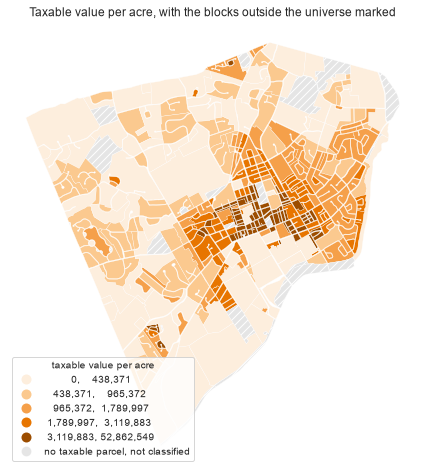

In [7]:
MISSING = {"color": "#e5e5e5", "hatch": "///", "edgecolor": "white", "label": "no taxable parcel, not classified"}

no_taxable = block_value["taxable"].isna()
print(f"{int(no_taxable.sum())} blocks have no taxable parcel, of which {int(block_value['total'].isna().sum())} received no parcel at all")

ax = block_value.plot(column="taxable_per_acre", scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.3,
                      figsize=(8, 8), legend=True, missing_kwds=MISSING,
                      legend_kwds={"loc": "lower left", "fmt": "{:,.0f}", "title": "taxable value per acre"})
ax.set_title("Taxable value per acre, with the blocks outside the universe marked")
ax.set_axis_off()

Now the campus is hatched, i.e. striped, and the legend says why. A reader can see at a glance that those blocks are not empty and not cheap; they are outside the universe of the map, and the map says so. Note that the hatched blocks are of two kinds. Most hold only exempt parcels, i.e. the campus, the schools and the churches, and a handful received no parcel centroid at all, because the block map covers some land that nobody pays tax on. The legend says no taxable parcel, which is true of both, and the caption will say the same. Note that a real zero also exists, i.e. a handful of blocks hold one vacant taxable parcel assessed at nothing, which is why the lowest class begins at 0 rather than above it. Those blocks are coloured, not hatched, because the map does know their value.

The lecture's phrase for this was that the legend should be exhaustive, i.e. every mark on the map should have a line in the legend, including the mark for "not classified". Note that geopandas draws legend entries as dots, so the legend's grey dot carries the label but not the stripes, and a poster going to print wants that patch redrawn.

## The map for the lobby

Now the poster. A finished map differs from a working map in its anatomy. It has a title that is a sentence, a legend that discloses the scheme, a scale bar, a north arrow, a caption that states the source and the four questions, and no axes. We build it in four short cells and then export it at poster quality.

First, the number the title is going to state. It is computed here, from the classified data, because a number typed into a title goes stale the next time the assessment file is refreshed and nobody notices. `yb` is the class each block landed in, numbered 0 to 4, so the third line compares the middle block of the top class with the middle block of the bottom one. The class upper bounds are printed as well, with the number of blocks in each class beside them, and the last of the five is the largest block rather than a cut, because at the end of the session an agent will report its own and you will want yours to hand:

In [8]:
rate = block_value["taxable_per_acre"].dropna()
classes = mapclassify.Quantiles(rate.values, k=5)
ratio = rate[classes.yb == 4].median() / rate[classes.yb == 0].median()

print("class upper bounds, dollars per acre ", [f"{b:,.0f}" for b in classes.bins])
print("blocks per class                     ", classes.counts.tolist())
print(f"median taxable value per acre, top class over bottom class: {ratio:.1f} times")
print(f"the pipeline recorded                                        {reference['blocks']['taxable_per_acre_ratio_top_to_bottom_class']} times")
print("top three blocks by taxable value per acre ", block_value["taxable_per_acre"].nlargest(3).round(0).to_dict())

class upper bounds, dollars per acre  ['438,371', '965,372', '1,789,997', '3,119,883', '52,862,549']
blocks per class                      [85, 85, 85, 85, 85]
median taxable value per acre, top class over bottom class: 21.0 times
the pipeline recorded                                        21.0 times
top three blocks by taxable value per acre  {'20.03': 52862549.0, '20.01': 26060608.0, '20.04': 23147833.0}


Read the breaks. The first four classes are narrow and the top one runs from about three million to fifty three million dollars per acre, i.e. quantiles guarantee that every class holds the same number of blocks, 85 of them here, and buy that with one very wide class at the top. The legend has to show the numbers for the map to be readable at all.

Note that the reference dictionary printed earlier also carries `per_acre_ratio_top_to_bottom_class`, which is the same computation on the total rather than the taxable value. The poster uses the taxable one, and the two differ because the campus is in one and not the other.

The body of the map, with the town's own road centrelines as the only backdrop and the town boundary closing the map. No basemap from a tile server, on purpose. At rehearsal three tile providers failed in a row and every one returned a valid image with an error message drawn on it, so a map that depends on a basemap is a map that can fail silently. The municipality's roads cannot:

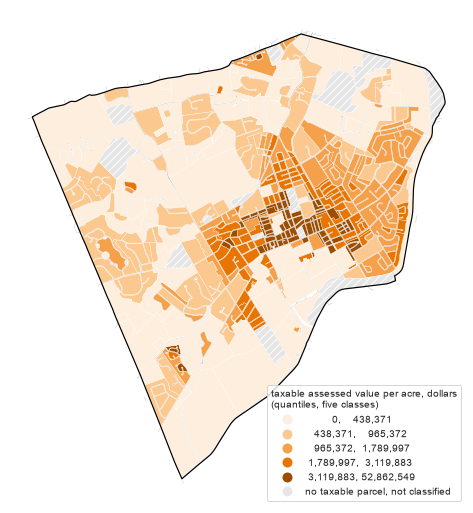

In [9]:
roads = gpd.read_file("data/princeton_municipal.gpkg", layer="roads").to_crs(metric)
boundary = gpd.read_file("data/princeton_boundary.geojson").to_crs(metric)

fig, ax = plt.subplots(figsize=(12, 9))
roads.plot(ax=ax, color="#bfbfbf", linewidth=0.4, zorder=1)
block_value.plot(column="taxable_per_acre", scheme="Quantiles", k=5, cmap=ORANGES, edgecolor="white", linewidth=0.3,
                 ax=ax, legend=True, missing_kwds=MISSING, zorder=2,
                 legend_kwds={"loc": "lower right", "fontsize": 10, "fmt": "{:,.0f}",
                              "title": "taxable assessed value per acre, dollars\n(quantiles, five classes)"})
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2, zorder=3)
ax.set_aspect("equal")
ax.set_axis_off()

The pattern is the one we read above, now with the streets showing through the gaps between blocks, because the block layer has the road rights of way clipped out, and with the town boundary closing the map. Note that the block outlines are the municipality's and the boundary is the State's, which is why a hatched block in the north east reaches past the town line, i.e. the sort of disagreement between two authorities that 02-05 takes up. There is still no title, no scale and no caption, so this is a working map and not yet the poster.

The scale bar and the north arrow, by hand, in three lines each. The bar is a line 1,000 units long, and it is a kilometre only because the axes are in metres. The same three lines in EPSG:4326 would draw a bar a thousand degrees long and label it a kilometre, which is one more reason the working system is metres and stated:

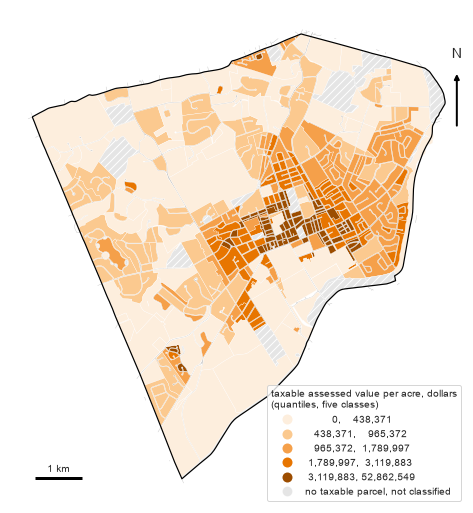

In [10]:
x0, y0 = ax.get_xlim()[0] + 600, ax.get_ylim()[0] + 600
ax.plot([x0, x0 + 1000], [y0, y0], color="black", linewidth=3, solid_capstyle="butt")
ax.text(x0 + 500, y0 + 130, "1 km", ha="center", fontsize=10)

xn, yn = ax.get_xlim()[1] - 200, ax.get_ylim()[1] - 2600
ax.text(xn, yn + 1500, "N", ha="center", fontsize=14)
ax.annotate("", xy=(xn, yn + 1200), xytext=(xn, yn), arrowprops=dict(arrowstyle="-|>", linewidth=2, color="black"))
fig

The bare `fig` on the last line asks the notebook to show the figure again with the additions drawn on it. Without it the cell adds the bar and the arrow and shows nothing, and you would think it had failed. Note that the arrow points to grid north, i.e. straight up the UTM grid, which at Princeton is a fraction of a degree from true north. On a town map nobody can see the difference. On a map of a whole state they can, and a careful caption says which north it is.

The title is a sentence with the computed number in it, and the caption states the four things the lecture's take-home card asks for, i.e. the coordinate system, the units, the denominator and the date, together with the source and with the universe, which is what the exempt rule leaves out. Every number in it is read from a variable rather than typed, except your name. Replace it in the first line before you run the cell:

Sources: parcels and assessments from NJGIN Open Data (MOD-IV, snapshot 2026-09-11); tax blocks and roads from the Municipality of Princeton (snapshot 2026-09-11); the town boundary from NJGIN Open Data. Taxable assessed value in dollars per acre of block area, area from geometry in EPSG:26918. Quantiles, five classes. Blocks with no taxable parcel are hatched and not classified. The title compares the median block of the top class with the median block of the bottom class. Map by your name, 2026-09-13.


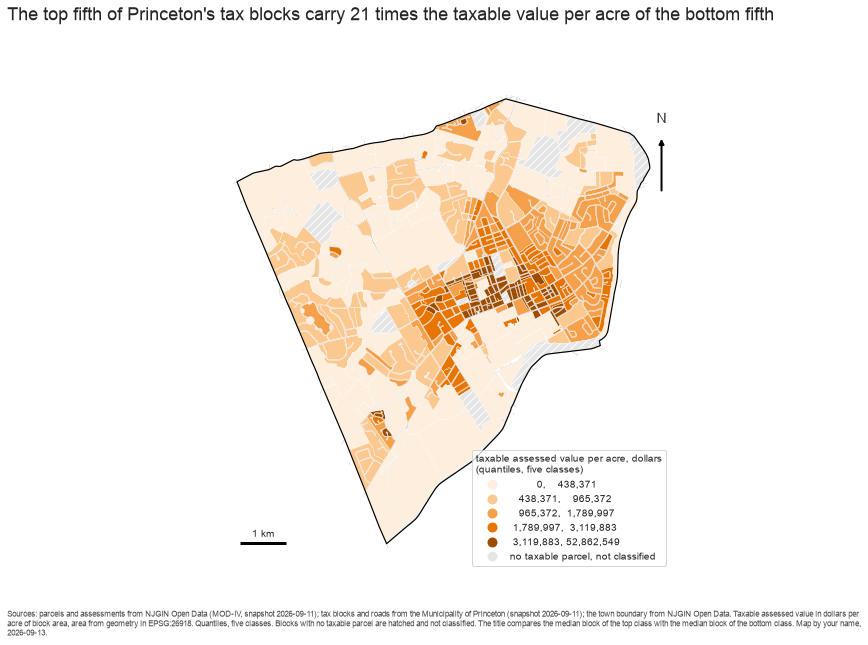

In [11]:
AUTHOR = "your name"   # replace this before you run the cell
for t in list(fig.texts): t.remove()   # so re-running this cell replaces the caption instead of stacking a second one

snapshots = reference["snapshots"]
caption = (
    f"Sources: parcels and assessments from NJGIN Open Data (MOD-IV, snapshot {snapshots['njgin']}); "
    f"tax blocks and roads from the Municipality of Princeton (snapshot {snapshots['municipal']}); the town boundary from NJGIN Open Data. "
    f"Taxable assessed value in dollars per acre of block area, area from geometry in {block_value.crs}. "
    f"Quantiles, five classes. Blocks with no taxable parcel are hatched and not classified. "
    f"The title compares the median block of the top class with the median block of the bottom class. "
    f"Map by {AUTHOR}, {date.today().isoformat()}."
)
print(caption)

fig.suptitle(f"The top fifth of Princeton's tax blocks carry {ratio:.0f} times the taxable value per acre of the bottom fifth",
             fontsize=18, x=0.01, ha="left")
fig.text(0.01, 0.01, caption, fontsize=8, color="0.3", wrap=True)
fig

Read the title as a reader in the lobby would. It makes one claim, the claim has a number in it, the number is the one the map shows, and every word in it names something the map measures. A first draft said downtown blocks and least dense blocks, and the map measures neither. It measures taxable value per acre, in fifths, and the title now says so. Then read the caption, printed in full above the figure so that you can copy it onto your handout, which is where the four questions live. If any of the four is missing, the map is not finished, however good it looks. Note that the second line of the cell removes whatever text the figure already carries before the title and the caption are drawn, so if you ran it once with the placeholder name, fixing the name and running it again replaces the caption rather than stacking a second one on top of the first.

## Exporting it

The poster's file type is PDF, which stores the map as shapes rather than pixels, so it prints sharp at any size. A PNG at 300 dots per inch goes beside it for slides and the notebook:

In [12]:
Path("output").mkdir(exist_ok=True)
fig.savefig("output/princeton_taxable_value_per_acre.pdf", bbox_inches="tight")
fig.savefig("output/princeton_taxable_value_per_acre.png", dpi=300, bbox_inches="tight", facecolor="white")

block_value.to_file("output/blocks_value_per_acre.gpkg", layer="blocks", driver="GPKG")
print(sorted(p.name for p in Path("output").iterdir()))

['blocks_value_per_acre.gpkg', 'princeton_taxable_value_per_acre.pdf', 'princeton_taxable_value_per_acre.png']


Three files: the poster PDF, the PNG, and the block layer itself as a GeoPackage, which is what the agent will be handed at the end of the session to see whether it can make this map in QGIS.

## The audit that finds only what it was written to find

One last cell. It checks that the caption states what a caption must, and it is here because a check that runs is better than a rule that is remembered. Read it, and then read the sentence after it:

In [13]:
for required in ("EPSG:", "dollar", "acre", "uantile", snapshots["njgin"]):   # no capital Q, so it matches Quantiles and quantiles
    assert required in caption, f"the caption does not state {required!r}"
print("the caption names the coordinate system, the units and denominator, the classification and the data's date")

the caption names the coordinate system, the units and denominator, the classification and the data's date


It passed, and it would have passed a caption with the wrong coordinate system in it, or the right words about a map of the wrong variable. An audit finds the errors it was written to find and is silent about the rest. The audit at the end of 01-04 had the same shape, i.e. each of its three checks caught the error it was written for and said nothing about the others, and so will every check you ever write. It is a floor, not a guarantee, and the rest of the guarantee is you.

## What is not on this map

Before you call the map finished, answer these in your own words, in a cell below or on paper. At rehearsal an agent produced a beautiful map of Princeton with a legend, a scale bar, a north arrow and a correct attribution, and no parks, no buildings and no railways, and nothing on the map said so. This list exists so that yours cannot do that.

- Which parcels are excluded from the colours, and does the legend say so?
- What can this map not show? Name three things.
- What might a reader wrongly conclude from it, and does the title or the caption stop them?
- Which of the four questions, coordinate system, units, denominator, date, would a reader have to guess at if the caption were lost?

## Check your understanding

1. Your first per-acre map left the campus blocks white with nothing in the legend. What would a reader in the lobby conclude, and what did `missing_kwds` change?
2. The scale bar is a line 1,000 units long. In which coordinate system is that a kilometre, and what would the same three lines draw in EPSG:4326?
3. The title contains a number that was computed, not typed. What goes wrong with a typed number the next time the assessment file is refreshed?
4. Name the four things the caption states, and for each name the failure from this course it would have caught.

## Where we are

You have made a choropleth on the municipality's own units with every decision made in the open, i.e. a rate rather than a total, a stated universe with the exempt blocks marked, a disclosed classification, a sequential ramp, and a caption that answers the four questions. You have exported it as the file the poster will be, and you have an audit that checks the caption and a list that checks what the audit cannot.

Whether the pattern on this map could have been made by shuffling the values over the blocks is a number, and 02-06 computes it. Whether the two authorities' parcel files agree with each other is a question, and 02-05 asks it. Both are self-paced and neither is assessed.

## Further resources

Nothing in this course requires anything below.

The matplotlib page on output backends explains which formats are vector and which are raster: https://matplotlib.org/stable/users/explain/figure/backends.html

The reference for `savefig` documents `dpi` and `bbox_inches`: https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html

The geopandas mapping guide documents `scheme`, `legend_kwds` and `missing_kwds`, which are the three keywords this notebook leaned on: https://geopandas.org/en/stable/docs/user_guide/mapping.html

New Jersey publishes each municipality's ratable base, i.e. its taxable assessed value, in the annual abstract of ratables, which is where a reader would check the total this map is built from: https://www.nj.gov/treasury/taxation/lpt/statdata.shtml

The parcels and assessments are published by NJGIN Open Data, which asks to be acknowledged, and so is the town boundary on the poster; the tax blocks and roads by the Municipality of Princeton.